<a href="https://colab.research.google.com/github/AntonyAroni/PFC_II/blob/Implementacion/parallelism_in_object_detection_using_vision_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ARONI JARATA ANTONY - PFC



# Object detection with Vision Transformers

**Description:** A simple Keras implementation of object detection using Vision Transformers.

In [ ]:
!pip install --upgrade tensorflow
!pip install --upgrade keras

## Imports and setup

In [ ]:
!pip install ops

In [ ]:
!pip install joblib

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]


import numpy as np
import keras
from keras import layers
from keras import ops
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import scipy.io
import shutil
from joblib import Parallel, delayed
from keras.utils import load_img, img_to_array

## Prepare dataset

We use the [Caltech 101 Dataset](https://data.caltech.edu/records/mzrjq-6wc02).

In [ ]:
# Path to images and annotations
path_images = "./101_ObjectCategories/airplanes/"
path_annot = "./Annotations/Airplanes_Side_2/"

path_to_downloaded_file = keras.utils.get_file(
    fname="caltech_101_zipped",
    origin="https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip",
    extract=True,
    archive_format="zip",  # downloaded file format
    cache_dir="/",  # cache and extract in current directory
)
download_base_dir = os.path.dirname(path_to_downloaded_file)

# Extracting tar files found inside main zip file
shutil.unpack_archive(
    os.path.join(download_base_dir,"caltech-101", "101_ObjectCategories.tar.gz"), "."
)

shutil.unpack_archive(
    os.path.join(download_base_dir,"caltech-101", "Annotations.tar"), "."
)

# list of paths to images and annotations
image_paths = [
    f for f in os.listdir(path_images) if os.path.isfile(os.path.join(path_images, f))
]
annot_paths = [
    f for f in os.listdir(path_annot) if os.path.isfile(os.path.join(path_annot, f))
]

image_paths.sort()
annot_paths.sort()

image_size = 224  # resize input images to this size

images, targets = [], []
# primer cambio

# Define la función de procesamiento para cada imagen y anotación
def process_annotation_and_image(annot_path, image_path, path_annot, path_images, image_size):
    annot = scipy.io.loadmat(path_annot + annot_path)["box_coord"][0]
    top_left_x, top_left_y = annot[2], annot[0]
    bottom_right_x, bottom_right_y = annot[3], annot[1]

    image = keras.utils.load_img(path_images + image_path)
    (w, h) = image.size

    # Redimensionar la imagen
    image = image.resize((image_size, image_size))
    image_array = keras.utils.img_to_array(image)

    # Escalar las coordenadas
    target = (
        float(top_left_x) / w,
        float(top_left_y) / h,
        float(bottom_right_x) / w,
        float(bottom_right_y) / h,
    )

    return image_array, target

# Paralelización del procesamiento de imágenes y anotaciones
results = Parallel(n_jobs=-1)(
    delayed(process_annotation_and_image)(annot_paths[i], image_paths[i], path_annot, path_images, image_size)
    for i in range(len(annot_paths))
)

# Separar los resultados
images, targets = zip(*results)

# Convertir a numpy arrays y dividir en datasets de entrenamiento y prueba
(x_train), (y_train) = (
    np.asarray(images[:int(len(images) * 0.8)]),
    np.asarray(targets[:int(len(targets) * 0.8)]),
)
(x_test), (y_test) = (
    np.asarray(images[int(len(images) * 0.8):]),
    np.asarray(targets[int(len(targets) * 0.8):]),
)

137414764/137414764 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


## Implement multilayer-perceptron (MLP)

We use the code from the Keras example
[Image classification with Vision Transformer](https://keras.io/examples/vision/image_classification_with_vision_transformer/)
as a reference.

In [ ]:

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


## Implement the patch creation layer

In [ ]:

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


## Display patches for an input image

Image size: 224 X 224
Patch size: 32 X 32
49 patches per image 
3072 elements per patch


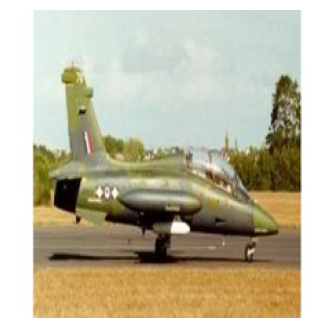

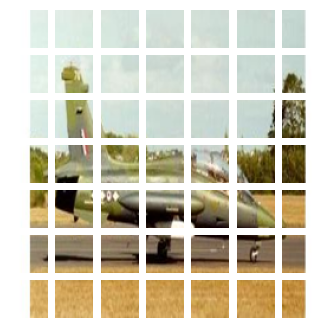

In [ ]:
patch_size = 32  # Size of the patches to be extracted from the input images

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0].astype("uint8"))
plt.axis("off")

patches = Patches(patch_size)(np.expand_dims(x_train[0], axis=0))
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"{patches.shape[1]} patches per image \n{patches.shape[-1]} elements per patch")


n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")

## Implement the patch encoding layer

The `PatchEncoder` layer linearly transforms a patch by projecting it into a
vector of size `projection_dim`. It also adds a learnable position
embedding to the projected vector.

In [ ]:

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    # Override function to avoid error while saving model
    def get_config(self):
        config = super().get_config().copy()
        config.update(
            {
                "input_shape": input_shape,
                "patch_size": patch_size,
                "num_patches": num_patches,
                "projection_dim": projection_dim,
                "num_heads": num_heads,
                "transformer_units": transformer_units,
                "transformer_layers": transformer_layers,
                "mlp_head_units": mlp_head_units,
            }
        )
        return config

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded


In [ ]:
#parallelism:
import tensorflow as tf
from tensorflow import keras


class Patches(keras.layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

## Build the ViT model

The ViT model has multiple Transformer blocks.
The `MultiHeadAttention` layer is used for self-attention,
applied to the sequence of image patches. The encoded patches (skip connection)
and self-attention layer outputs are normalized and fed into a
multilayer perceptron (MLP).
The model outputs four dimensions representing
the bounding box coordinates of an object.

In [ ]:

def create_vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
):
    inputs = keras.Input(shape=input_shape)
    # Create patches
    patches = Patches(patch_size)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.3)

    bounding_box = layers.Dense(4)(
        features
    )  # Final four neurons that output bounding box

    # return Keras model.
    return keras.Model(inputs=inputs, outputs=bounding_box)


## Run the experiment (parallelism - gpu's)

In [ ]:
import tensorflow as tf

# Usar MirroredStrategy para entrenamiento con múltiples GPUs
strategy = tf.distribute.MirroredStrategy()

# Ver cuántas GPUs están disponibles
print('Número de dispositivos disponibles: ', strategy.num_replicas_in_sync)

# Dentro del alcance de la estrategia, compilar y entrenar el modelo
with strategy.scope():
    vit_object_detector = create_vit_object_detector(
        input_shape,
        patch_size,
        num_patches,
        projection_dim,
        num_heads,
        transformer_units,
        transformer_layers,
        mlp_head_units,
    )

    # Configurar el optimizador y el modelo
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )
    vit_object_detector.compile(optimizer=optimizer, loss=keras.losses.MeanSquaredError())

    checkpoint_filepath = "vit_object_detector.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    )

    # Entrenar el modelo
    history = vit_object_detector.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback, keras.callbacks.EarlyStopping(monitor="val_loss", patience=10)],
    )


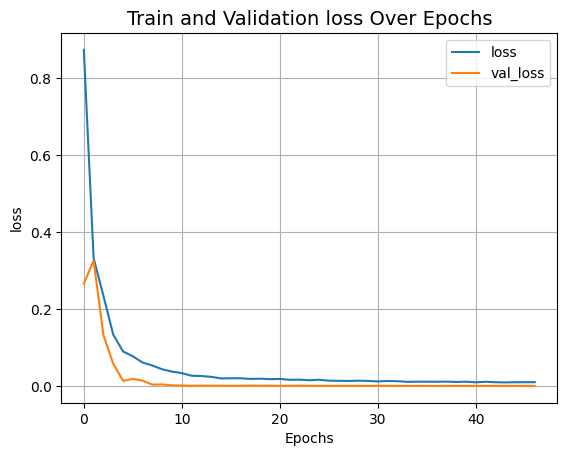

In [ ]:
def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_history("loss")

## Run the experiment without parallelism or distribution

In [ ]:

def run_experiment(model, learning_rate, weight_decay, batch_size, num_epochs):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    # Compile model.
    model.compile(optimizer=optimizer, loss=keras.losses.MeanSquaredError())

    checkpoint_filepath = "vit_object_detector.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[
            checkpoint_callback,
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=10),
        ],
    )

    return history


input_shape = (image_size, image_size, 3)  # input image shape
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 32
num_epochs = 100
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
# Size of the transformer layers
transformer_units = [
    projection_dim * 2,
    projection_dim,
]
transformer_layers = 4
mlp_head_units = [2048, 1024, 512, 64, 32]  # Size of the dense layers


history = []
num_patches = (image_size // patch_size) ** 2

vit_object_detector = create_vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
)

# Train model
history = run_experiment(
    vit_object_detector, learning_rate, weight_decay, batch_size, num_epochs
)





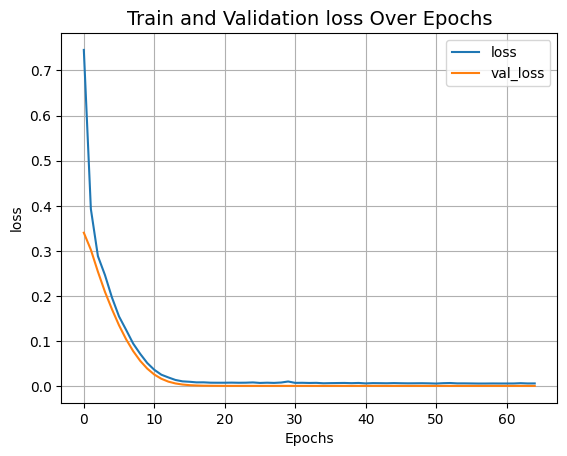

In [ ]:
def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_history("loss")

## Evaluate the model with parallelism

In [ ]:
from joblib import Parallel, delayed
import matplotlib.patches as patches
import scipy.io
import keras.utils
import os
import cv2
import numpy as np

def process_image(i, input_image, vit_object_detector, x_test, y_test, image_size):
    # Acciones necesarias para serializar el proceso
    im = keras.utils.img_to_array(input_image)
    preds = vit_object_detector.predict(np.expand_dims(input_image, axis=0))[0]

    (h, w) = input_image.shape[0:2]

    top_left_x, top_left_y = int(preds[0] * w), int(preds[1] * h)
    bottom_right_x, bottom_right_y = int(preds[2] * w), int(preds[3] * h)
    box_predicted = [top_left_x, top_left_y, bottom_right_x, bottom_right_y]

    top_left_x, top_left_y = int(y_test[i][0] * w), int(y_test[i][1] * h)
    bottom_right_x, bottom_right_y = int(y_test[i][2] * w), int(y_test[i][3] * h)
    box_truth = [top_left_x, top_left_y, bottom_right_x, bottom_right_y]

    iou = bounding_box_intersection_over_union(box_predicted, box_truth)

    return i, im, box_predicted, box_truth, iou

# Paralelización del procesamiento de imágenes
results = Parallel(n_jobs=-1)(
    delayed(process_image)(i, x_test[i], vit_object_detector, x_test, y_test, image_size)
    for i in range(10)
)

# Visualización de los resultados
mean_iou = 0
fig, axs = plt.subplots(10, 2, figsize=(15, 25))

for i, im, box_predicted, box_truth, iou in results:
    ax1, ax2 = axs[i]

    ax1.imshow(im.astype("uint8"))
    rect = patches.Rectangle(
        (box_predicted[0], box_predicted[1]),
        box_predicted[2] - box_predicted[0],
        box_predicted[3] - box_predicted[1],
        facecolor="none",
        edgecolor="red",
        linewidth=1,
    )
    ax1.add_patch(rect)
    ax1.set_xlabel(f"Predicted: {box_predicted}, IoU: {iou:.4f}")

    ax2.imshow(im.astype("uint8"))
    rect = patches.Rectangle(
        (box_truth[0], box_truth[1]),
        box_truth[2] - box_truth[0],
        box_truth[3] - box_truth[1],
        facecolor="none",
        edgecolor="blue",
        linewidth=1,
    )
    ax2.add_patch(rect)
    ax2.set_xlabel(f"Ground Truth: {box_truth}, IoU: {iou:.4f}\nIoU: {iou:.4f}")

    mean_iou += iou

# Calcular y mostrar el IoU promedio
print(f"Mean IoU: {mean_iou / 10}")
plt.show()


## Evaluate the model (normal version)

In [ ]:
import matplotlib.patches as patches

# Saves the model in current path
vit_object_detector.save("vit_object_detector.keras")


# To calculate IoU (intersection over union, given two bounding boxes)
def bounding_box_intersection_over_union(box_predicted, box_truth):
    # get (x, y) coordinates of intersection of bounding boxes
    top_x_intersect = max(box_predicted[0], box_truth[0])
    top_y_intersect = max(box_predicted[1], box_truth[1])
    bottom_x_intersect = min(box_predicted[2], box_truth[2])
    bottom_y_intersect = min(box_predicted[3], box_truth[3])

    # calculate area of the intersection bb (bounding box)
    intersection_area = max(0, bottom_x_intersect - top_x_intersect + 1) * max(
        0, bottom_y_intersect - top_y_intersect + 1
    )

    # calculate area of the prediction bb and ground-truth bb
    box_predicted_area = (box_predicted[2] - box_predicted[0] + 1) * (
        box_predicted[3] - box_predicted[1] + 1
    )
    box_truth_area = (box_truth[2] - box_truth[0] + 1) * (
        box_truth[3] - box_truth[1] + 1
    )

    # calculate intersection over union by taking intersection
    # area and dividing it by the sum of predicted bb and ground truth
    # bb areas subtracted by  the interesection area

    # return ioU
    return intersection_area / float(
        box_predicted_area + box_truth_area - intersection_area
    )


i, mean_iou = 0, 0



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
mean_iou: 1.1929637435950105


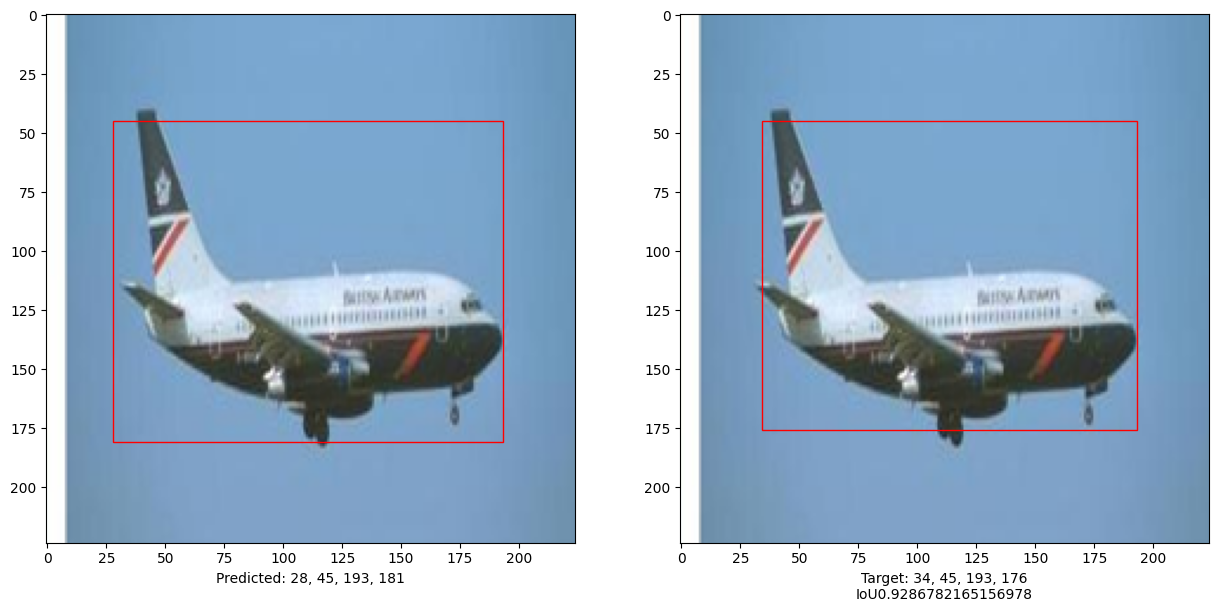

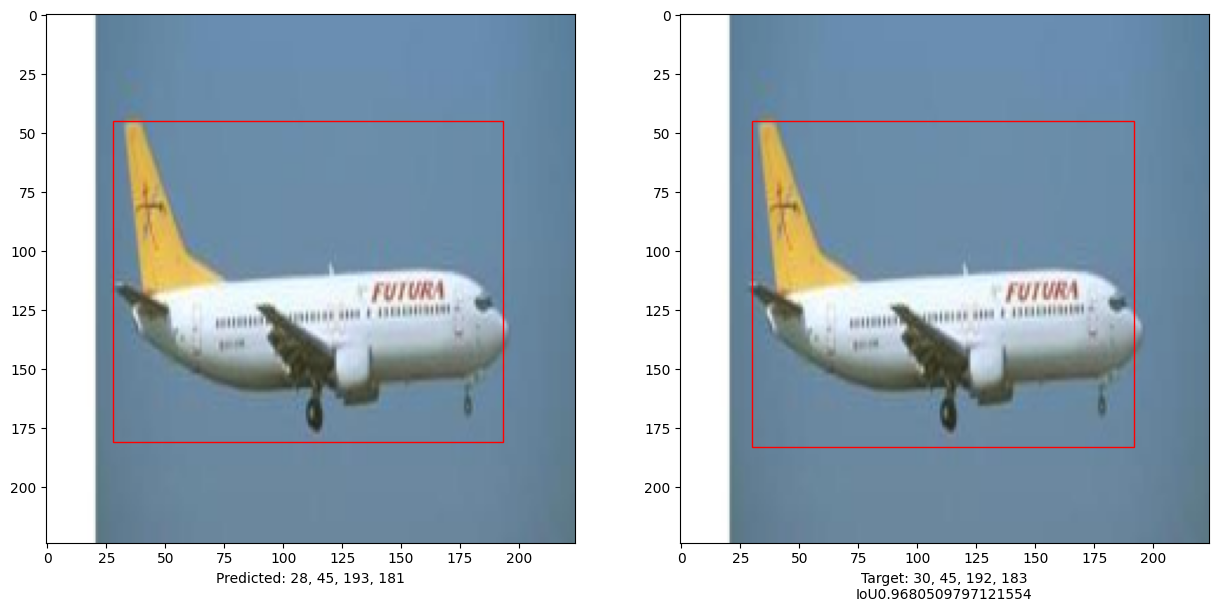

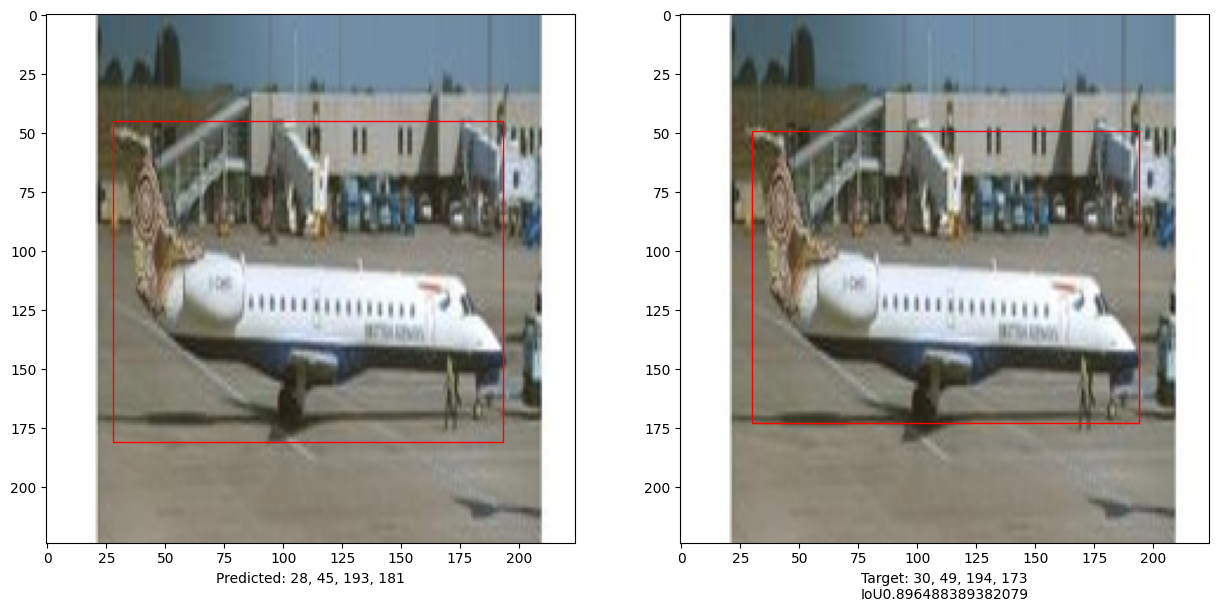

In [ ]:
# Compare results for 10 images in the test set
for input_image in x_test[:3]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 15))
    im = input_image

    # Display the image
    ax1.imshow(im.astype("uint8"))
    ax2.imshow(im.astype("uint8"))

    input_image = cv2.resize(
        input_image, (image_size, image_size), interpolation=cv2.INTER_AREA
    )
    input_image = np.expand_dims(input_image, axis=0)
    preds = vit_object_detector.predict(input_image)[0]

    (h, w) = (im).shape[0:2]

    top_left_x, top_left_y = int(preds[0] * w), int(preds[1] * h)

    bottom_right_x, bottom_right_y = int(preds[2] * w), int(preds[3] * h)

    box_predicted = [top_left_x, top_left_y, bottom_right_x, bottom_right_y]
    # Create the bounding box
    rect = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor="none",
        edgecolor="red",
        linewidth=1,
    )
    # Add the bounding box to the image
    ax1.add_patch(rect)
    ax1.set_xlabel(
        "Predicted: "
        + str(top_left_x)
        + ", "
        + str(top_left_y)
        + ", "
        + str(bottom_right_x)
        + ", "
        + str(bottom_right_y)
    )

    top_left_x, top_left_y = int(y_test[i][0] * w), int(y_test[i][1] * h)

    bottom_right_x, bottom_right_y = int(y_test[i][2] * w), int(y_test[i][3] * h)

    box_truth = top_left_x, top_left_y, bottom_right_x, bottom_right_y

    mean_iou += bounding_box_intersection_over_union(box_predicted, box_truth)
    # Create the bounding box
    rect = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor="none",
        edgecolor="red",
        linewidth=1,
    )
    # Add the bounding box to the image
    ax2.add_patch(rect)
    ax2.set_xlabel(
        "Target: "
        + str(top_left_x)
        + ", "
        + str(top_left_y)
        + ", "
        + str(bottom_right_x)
        + ", "
        + str(bottom_right_y)
        + "\n"
        + "IoU"
        + str(bounding_box_intersection_over_union(box_predicted, box_truth))
    )
    i = i + 1

print("mean_iou: " + str(mean_iou / len(x_test[:10])))
plt.show()

This example demonstrates that a pure Transformer can be trained
to predict the bounding boxes of an object in a given image,
thus extending the use of Transformers to object detection tasks.
The model can be improved further by tuning hyper-parameters and pre-training.

In [ ]:
import matplotlib.patches as patches

# Función para calcular IoU
def bounding_box_intersection_over_union(box_predicted, box_truth):
    top_x_intersect = max(box_predicted[0], box_truth[0])
    top_y_intersect = max(box_predicted[1], box_truth[1])
    bottom_x_intersect = min(box_predicted[2], box_truth[2])
    bottom_y_intersect = min(box_predicted[3], box_truth[3])
    intersection_area = max(0, bottom_x_intersect - top_x_intersect + 1) * max(0, bottom_y_intersect - top_y_intersect + 1)
    box_predicted_area = (box_predicted[2] - box_predicted[0] + 1) * (box_predicted[3] - box_predicted[1] + 1)
    box_truth_area = (box_truth[2] - box_truth[0] + 1) * (box_truth[3] - box_truth[1] + 1)
    return intersection_area / float(box_predicted_area + box_truth_area - intersection_area)

# Evaluar el modelo en imágenes de prueba
def evaluate_model(model, x_test, y_test):
    ious = []
    for i, input_image in enumerate(x_test):
        input_image_resized = cv2.resize(input_image, (image_size, image_size), interpolation=cv2.INTER_AREA)
        input_image_resized = np.expand_dims(input_image_resized, axis=0)
        preds = model.predict(input_image_resized)[0]
        (h, w) = input_image.shape[0:2]
        box_predicted = [int(preds[0] * w), int(preds[1] * h), int(preds[2] * w), int(preds[3] * h)]
        box_truth = [int(y_test[i][0] * w), int(y_test[i][1] * h), int(y_test[i][2] * w), int(y_test[i][3] * h)]
        iou = bounding_box_intersection_over_union(box_predicted, box_truth)
        ious.append((iou, input_image, box_predicted, box_truth))
    return ious

# Obtener los mejores, promedio y peores casos
ious = evaluate_model(vit_object_detector, x_test, y_test)
ious.sort(key=lambda x: x[0], reverse=True)

best_case = ious[0]
average_case = ious[len(ious) // 2]
worst_case = ious[-1]




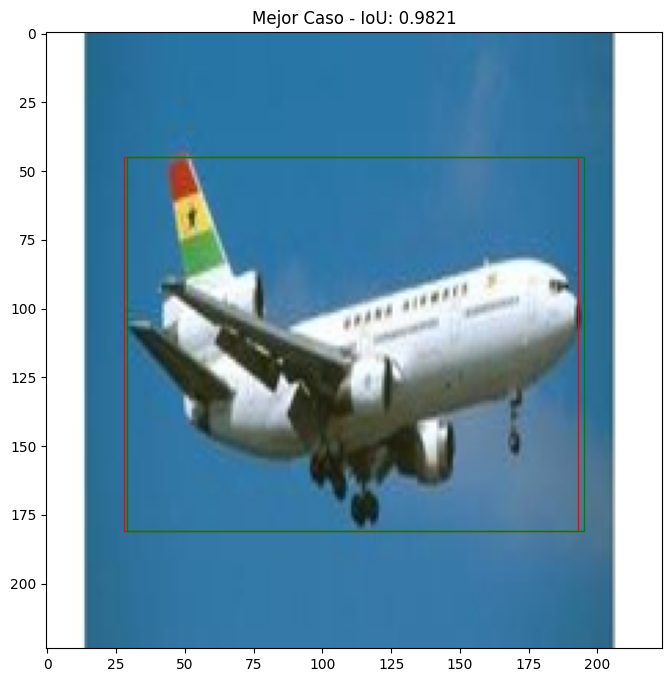

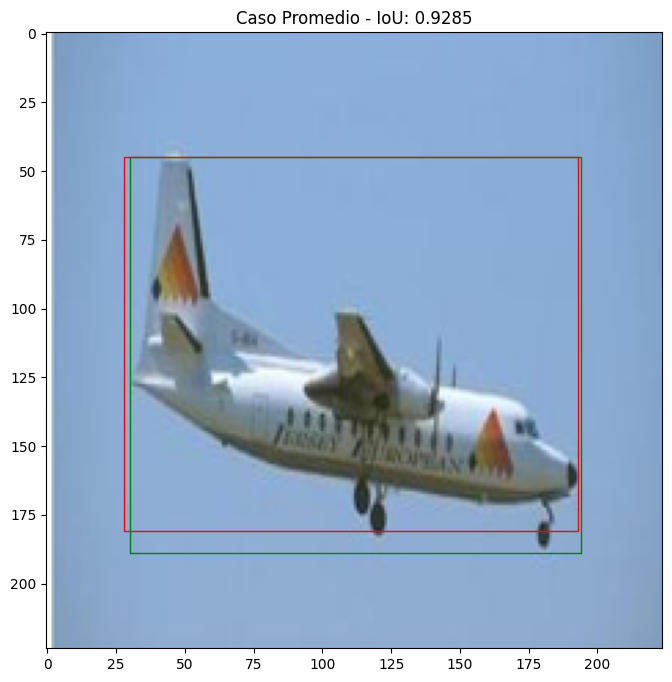

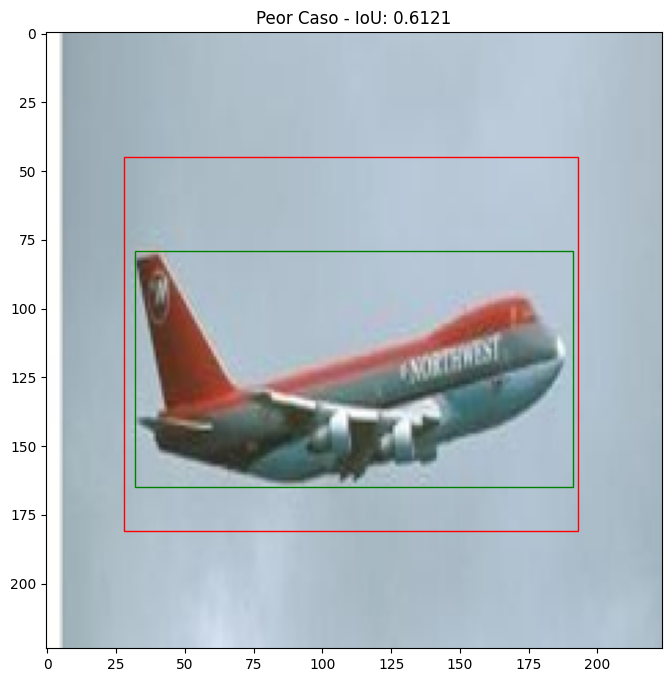

In [ ]:
# Mostrar los resultados
def display_case(case, title):
    iou, image, box_predicted, box_truth = case
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(image.astype("uint8"))
    rect_pred = patches.Rectangle((box_predicted[0], box_predicted[1]), box_predicted[2] - box_predicted[0], box_predicted[3] - box_predicted[1], edgecolor='r', facecolor='none')
    rect_truth = patches.Rectangle((box_truth[0], box_truth[1]), box_truth[2] - box_truth[0], box_truth[3] - box_truth[1], edgecolor='g', facecolor='none')
    ax.add_patch(rect_pred)
    ax.add_patch(rect_truth)
    ax.set_title(f"{title} - IoU: {iou:.4f}")
    plt.show()

display_case(best_case, "Mejor Caso")
display_case(average_case, "Caso Promedio")
display_case(worst_case, "Peor Caso")